# Medical Insurance Cost Prediction — Random Forest Regressor (Bagging Ensemble)

**Dataset:** [Medical Insurance Cost Prediction](https://www.kaggle.com/datasets/mohankrishnathalla/medical-insurance-cost-prediction) (Mohan Krishna Thalla)

**Goal:** Predict **annual medical cost** using a **Random Forest Regressor**. Random Forest is a **bagging** (Bootstrap AGGregatING) ensemble: it trains many decision trees on bootstrap samples of the data and averages their predictions, with extra randomness from feature subsampling at each split.


## 1. Load the CSV — Google Drive (no Kaggle token) or Kaggle

### Option A — Google Drive

Upload your `.csv` to Drive, set `USE_GOOGLE_DRIVE = True` and `DRIVE_CSV_PATH` (e.g. `/content/drive/MyDrive/.../file.csv`), run the next cell, and allow Drive access when prompted.

### Option B — Kaggle API

Set `USE_GOOGLE_DRIVE = False` in the next cell, then run it. You will need `kaggle.json` (Kaggle → Account → **Create New API Token**) or Colab **Secrets** as described in the optional block inside that cell.

In [1]:
import glob
import os
import subprocess

import pandas as pd

# ----- Choose data source -----
USE_GOOGLE_DRIVE = True
# Full path to your CSV after Drive is mounted (edit folder + filename)
DRIVE_CSV_PATH = "/content/drive/MyDrive/ML_Project/medical_insurance.csv"


def _sh(cmd: str) -> None:
    subprocess.run(cmd, shell=True, check=True)


if USE_GOOGLE_DRIVE:
    from google.colab import drive

    drive.mount("/content/drive")
    df = pd.read_csv(DRIVE_CSV_PATH)
    print("Loaded from Google Drive:", DRIVE_CSV_PATH)
else:
    _sh("pip install -q kaggle")
    if not os.path.exists("/root/.kaggle/kaggle.json"):
        from google.colab import files

        os.makedirs("/root/.kaggle", exist_ok=True)
        uploaded = files.upload()  # upload kaggle.json
        _sh("mv -f kaggle.json /root/.kaggle/kaggle.json")
        _sh("chmod 600 /root/.kaggle/kaggle.json")

    # Optional: Colab Secrets instead of upload (uncomment)
    # from google.colab import userdata
    # os.makedirs("/root/.kaggle", exist_ok=True)
    # open("/root/.kaggle/kaggle.json", "w").write(
    #     '{"username":"' + userdata.get("KAGGLE_USERNAME") + '","key":"' + userdata.get("KAGGLE_KEY") + '"}'
    # )
    # _sh("chmod 600 /root/.kaggle/kaggle.json")

    _sh(
        "kaggle datasets download -d mohankrishnathalla/medical-insurance-cost-prediction"
    )
    _sh("unzip -o medical-insurance-cost-prediction.zip -d medical_insurance_data")
    csv_paths = glob.glob("medical_insurance_data/**/*.csv", recursive=True)
    if not csv_paths:
        csv_paths = glob.glob("**/*.csv", recursive=True)
    assert csv_paths, "No CSV found after Kaggle download."
    df = pd.read_csv(csv_paths[0])
    print("Loaded from Kaggle extract:", csv_paths[0])

df.head()

Mounted at /content/drive
Loaded from Google Drive: /content/drive/MyDrive/ML_Project/medical_insurance.csv


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


## 2. Import Libraries

`df` was created in section 1. Run that cell first.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

assert "df" in globals(), "Run section 1 first to create `df`."


In [3]:
print(df.shape)
print(df.dtypes)
df.info()
df.describe(include="all")

(100000, 54)
person_id                        int64
age                              int64
sex                             object
region                          object
urban_rural                     object
income                         float64
education                       object
marital_status                  object
employment_status               object
household_size                   int64
dependents                       int64
bmi                            float64
smoker                          object
alcohol_freq                    object
visits_last_year                 int64
hospitalizations_last_3yrs       int64
days_hospitalized_last_3yrs      int64
medication_count                 int64
systolic_bp                    float64
diastolic_bp                   float64
ldl                            float64
hba1c                          float64
plan_type                       object
network_tier                    object
deductible                       int64
copay       

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,100000,100000,100000,1.000000e+05,100000,100000,100000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
unique,NaN,NaN,3,5,3,NaN,6,4,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Female,South,Urban,NaN,Bachelors,Married,Employed,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,49193,28029,60019,NaN,27996,53252,55269,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,50000.500000,47.521500,NaN,NaN,NaN,4.987390e+04,NaN,NaN,NaN,2.430900,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,NaN,NaN,NaN,4.680021e+04,NaN,NaN,NaN,1.075126,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,NaN,NaN,NaN,1.100000e+03,NaN,NaN,NaN,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,NaN,NaN,NaN,2.110000e+04,NaN,NaN,NaN,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,NaN,NaN,NaN,3.620000e+04,NaN,NaN,NaN,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,NaN,NaN,NaN,6.220000e+04,NaN,NaN,NaN,3.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000


## 3. Target column: `annual_medical_cost`

Some versions of this dataset name the target **`charges`**. This cell picks **`annual_medical_cost`** if present, otherwise **`charges`** (and renames for consistency).

In [4]:
TARGET_CANDIDATES = ["annual_medical_cost", "charges", "Annual_medical_cost"]
target_col = next((c for c in TARGET_CANDIDATES if c in df.columns), None)
if target_col is None:
    raise ValueError(
        "Could not find target column. Columns are: " + str(list(df.columns))
    )

if target_col != "annual_medical_cost":
    df = df.rename(columns={target_col: "annual_medical_cost"})

print("Target column:", "annual_medical_cost")
df["annual_medical_cost"].describe()

Target column: annual_medical_cost


,annual_medical_cost
count,100000.000000
mean,3009.451907
std,3127.462822
min,55.550000
25%,1175.117500
50%,2082.575000
75%,3707.957500
max,65724.900000


In [5]:
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])
if missing.sum() == 0:
    print("No missing values.")

Missing values per column:
 alcohol_freq    30083
dtype: int64


## 4. Data preprocessing

This section prepares data for modeling in two steps:

- **4.1 — Feature matrix and target:** build X (input features) and y (annual_medical_cost), and **drop** columns that should not be used as inputs (e.g. IDs, leakage-related fields).
- **4.2 — Split and encoding:** split into **train / validation / test** (70% / 10% / 20%), then **fit** numeric passthrough + **one-hot** categoricals **only on the training split** and transform all splits (X_train_proc, …).

Numeric columns pass through; categoricals are **one-hot encoded**.

### 4.1 Feature matrix and target

Define the **target** `y` and **feature matrix** `X`. First, missing **`alcohol_freq`** values are filled with **`Unknown`** so one-hot encoding sees a real category. Then columns that must not be used as inputs are **dropped** (IDs, premiums, claims totals, etc., if present).


In [6]:
print(
    "\nnote: Outcome from previous cell gave missing values in dataset analysis. "
    "Handling missing values in the next step before encoding categorical features."
)

if "alcohol_freq" in df.columns:
    print("\nAlcohol frequency before handling:")
    print(df["alcohol_freq"].value_counts(dropna=False))

    df["alcohol_freq"] = df["alcohol_freq"].fillna("Unknown")

    print("\nAlcohol frequency after handling:")
    print(df["alcohol_freq"].value_counts())

print(f"\nRemaining missing values: {df.isnull().sum().sum()}")

y = df["annual_medical_cost"].values

# Ignore these columns in feature selection (if present in dataset)
DROP_FEATURES = [
    "person_id",
    "policy_term_years",
    "policy_changes_last_2yrs",
    "provider_quality",
    "annual_premium",
    "monthly_premium",
    "claims_count",
    "avg_claim_amount",
    "total_claims_paid",
    "risk_score",
]

existing_drop_features = [c for c in DROP_FEATURES if c in df.columns]
X = df.drop(columns=["annual_medical_cost", *existing_drop_features], errors="ignore")

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Dropped features:", existing_drop_features)
print("Using feature count:", X.shape[1])
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)


note: Outcome from previous cell gave missing values in dataset analysis. Handling missing values in the next step before encoding categorical features.

Alcohol frequency before handling:
alcohol_freq
Occasional    45078
NaN           30083
Weekly        19833
Daily          5006
Name: count, dtype: int64

Alcohol frequency after handling:
alcohol_freq
Occasional    45078
Unknown       30083
Weekly        19833
Daily          5006
Name: count, dtype: int64

Remaining missing values: 0
Dropped features: ['person_id', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'risk_score']
Using feature count: 43
Numeric: ['age', 'income', 'household_size', 'dependents', 'bmi', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'deductible', 'copay', 'chronic_count', 'hypertension', 'diab

### 4.2 Train / validation / test split and one-hot encoding (fit once)

We **split** the data first, then **fit preprocessing only on the training set** (numeric passthrough + one-hot for categoricals). Validation and test are **transformed** with the same fitted encoder so there is no data leakage.

The **model training** step is in **section 5**; it uses the encoded matrices (X_train_proc, …) so one-hot encoding is **not** repeated inside every hyperparameter combination.

In [7]:
RANDOM_STATE = 42

# 70% train, 30% held out — then split held-out into 10% val and 20% test (of full data)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=2 / 3,
    random_state=RANDOM_STATE,
)

n_total = len(X)
print(
    f"Train:      {len(X_train):5d} ({100 * len(X_train) / n_total:.1f}%)\n"
    f"Validation: {len(X_val):5d} ({100 * len(X_val) / n_total:.1f}%)\n"
    f"Test:       {len(X_test):5d} ({100 * len(X_test) / n_total:.1f}%)"
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

preprocessor.fit(X_train)
X_train_proc = preprocessor.transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

feature_names_out = preprocessor.get_feature_names_out()
print("Encoded feature count:", len(feature_names_out))
print("Train matrix shape (after preprocessing):", X_train_proc.shape)


Train:      70000 (70.0%)
Validation: 10000 (10.0%)
Test:       20000 (20.0%)
Encoded feature count: 73
Train matrix shape (after preprocessing): (70000, 73)


## 5. Model training (Random Forest hyperparameter search)

Search over the same **hyperparameter grid** as before. Each candidate is a RandomForestRegressor trained on **X_train_proc** (preprocessed in **section 4.2**). The best settings are chosen using **validation** performance, then the final model is refit on the training data.

Hyperparameter grid: 108 combinations (each trains a Random Forest on encoded training data). Preprocessing is already done in section 4.2.
Chosen Random Forest hyperparameters:
{'n_estimators': np.int64(300), 'max_depth': np.int64(8), 'min_samples_leaf': np.int64(2), 'min_samples_split': np.int64(5), 'max_features': 0.5}
Validation RMSE: $2,836.71 | Validation R²: 0.1503 | Train–Validation R² gap: 0.0890


,n_estimators,max_depth,min_samples_leaf,min_samples_split,max_features,train_rmse,val_rmse,train_r2,val_r2,generalization_gap
0,300,8,2,5,0.5,"$2,708.20","$2,836.71",0.239380,0.150349,0.089031
1,300,8,10,5,0.5,"$2,745.05","$2,837.07",0.218536,0.150135,0.068401
2,300,8,10,10,0.5,"$2,745.05","$2,837.07",0.218536,0.150135,0.068401
3,300,8,10,20,0.5,"$2,745.05","$2,837.07",0.218536,0.150135,0.068401
4,300,8,5,5,0.5,"$2,726.71","$2,837.07",0.228949,0.150133,0.078816
5,300,8,5,10,0.5,"$2,726.71","$2,837.07",0.228949,0.150133,0.078816
6,300,8,2,10,0.5,"$2,719.73","$2,837.33",0.232890,0.149979,0.082911
7,200,8,2,5,0.5,"$2,707.83","$2,837.35",0.239585,0.149968,0.089616
8,200,8,10,5,0.5,"$2,745.56","$2,837.39",0.218251,0.149941,0.068310
9,200,8,10,10,0.5,"$2,745.56","$2,837.39",0.218251,0.149941,0.068310


Chosen model: best validation RMSE out of 108 combinations (rank #1).


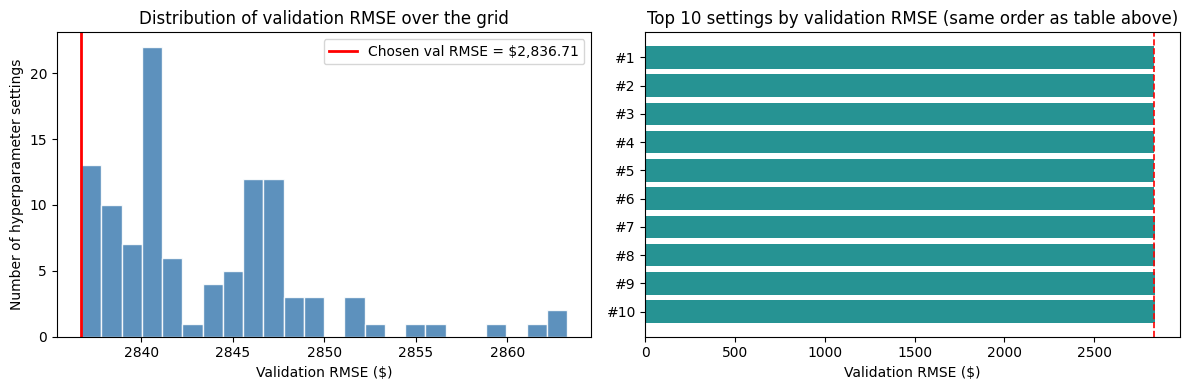

In [9]:
# Section 5: Random Forest hyperparameter search (on preprocessed data only)
# Each candidate is a RandomForestRegressor fit on X_train_proc — encoding is not repeated per grid combination.

def build_rf_pipeline(params=None):
    params = params or {}
    rf = RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **params,
    )
    return Pipeline([("regressor", rf)])


param_grid = {
    # How many trees in the forest; more → usually more stable predictions, slower to train
    "n_estimators": [200, 300],
    # Max depth of each tree; smaller → simpler trees, less overfitting risk
    "max_depth": [8, 12, 16],
    # Minimum samples in a leaf; larger → smoother leaves, less memorization
    "min_samples_leaf": [2, 5, 10],
    # Minimum samples to allow a split; larger → fewer splits, simpler trees
    "min_samples_split": [5, 10, 20],
    # Features considered at each split: sqrt(n_features) or 50%; core Random Forest randomness
    "max_features": ["sqrt", 0.5],
}

n_grid = int(np.prod([len(v) for v in param_grid.values()]))
print(
    f"Hyperparameter grid: {n_grid} combinations (each trains a Random Forest on encoded training data). "
    "Preprocessing is already done in section 4.2."
)

search_results = []
for params in ParameterGrid(param_grid):
    candidate_model = build_rf_pipeline(params)
    candidate_model.fit(X_train_proc, y_train)

    train_pred = candidate_model.predict(X_train_proc)
    val_pred = candidate_model.predict(X_val_proc)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    train_r2 = r2_score(y_train, train_pred)
    val_r2 = r2_score(y_val, val_pred)

    search_results.append(
        {
            **params,
            "train_rmse": train_rmse,
            "val_rmse": val_rmse,
            "train_r2": train_r2,
            "val_r2": val_r2,
            "generalization_gap": train_r2 - val_r2,
        }
    )
    del candidate_model

results_df = pd.DataFrame(search_results).sort_values(
    by=["val_rmse", "generalization_gap", "train_rmse"],
    ascending=[True, True, True],
).reset_index(drop=True)

best_result = results_df.iloc[0]
best_params = {
    key: best_result[key]
    for key in ["n_estimators", "max_depth", "min_samples_leaf", "min_samples_split", "max_features"]
}
model = build_rf_pipeline(best_params)
model.fit(X_train_proc, y_train)

print("Chosen Random Forest hyperparameters:")
print(best_params)
print(
    f"Validation RMSE: ${best_result['val_rmse']:,.2f} | "
    f"Validation R²: {best_result['val_r2']:.4f} | "
    f"Train–Validation R² gap: {best_result['generalization_gap']:.4f}"
)

_top10 = results_df[
    [
        "n_estimators",
        "max_depth",
        "min_samples_leaf",
        "min_samples_split",
        "max_features",
        "train_rmse",
        "val_rmse",
        "train_r2",
        "val_r2",
        "generalization_gap",
    ]
].head(10).copy()
_top10["train_rmse"] = _top10["train_rmse"].map(lambda x: f"${x:,.2f}")
_top10["val_rmse"] = _top10["val_rmse"].map(lambda x: f"${x:,.2f}")
display(_top10)

# Where the chosen model sits among all grid runs (same data as full results_df)
n_searched = len(results_df)
print(
    f"Chosen model: best validation RMSE out of {n_searched} combinations (rank #1)."
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(results_df["val_rmse"], bins=24, color="steelblue", edgecolor="white", alpha=0.88)
axes[0].axvline(
    best_result["val_rmse"],
    color="red",
    linewidth=2,
    label=f"Chosen val RMSE = ${best_result['val_rmse']:,.2f}",
)
axes[0].set_xlabel("Validation RMSE ($)")
axes[0].set_ylabel("Number of hyperparameter settings")
axes[0].set_title("Distribution of validation RMSE over the grid")
axes[0].legend()

top_n = min(10, len(results_df))
top = results_df.head(top_n).iloc[::-1]
y_pos = np.arange(top_n)
axes[1].barh(y_pos, top["val_rmse"], color="teal", alpha=0.85)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([f"#{top_n - i}" for i in range(top_n)])
axes[1].set_xlabel("Validation RMSE ($)")
axes[1].set_title("Top 10 settings by validation RMSE (same order as table above)")
axes[1].axvline(best_result["val_rmse"], color="red", linestyle="--", linewidth=1.2)
plt.tight_layout()
plt.show()


## 6. Evaluation — statistics and graphs

**Metrics:** MAE, MSE, RMSE, and R² on **train**, **validation**, and **test** for the **tuned** random forest. **MAE** and **RMSE** are printed as **dollars** (`$`, two decimals).

**Overfitting check:** compare train vs validation/test. A healthy model should still do best on train, but the gap should be noticeably smaller than the untuned model.

**Plots:** metric comparison, actual vs predicted for each split, and residual diagnostics on the **test** set.


All splits metrics (MAE and RMSE in dollars):
                  MAE             MSE       RMSE      R²
Split                                                   
train       $1,724.99  7,334,335.4665  $2,708.20  0.2394
validation  $1,774.90  8,046,945.0424  $2,836.71  0.1503
test        $1,776.79  8,630,656.7607  $2,937.80  0.1717

Train–Validation R² gap: 0.0890
Interpretation: the train and validation scores are reasonably close, so the fit is more balanced.

Test set metrics (requested):
MAE:  $1,776.79
MSE:  8,630,656.7607
RMSE: $2,937.80
R²:   0.1717


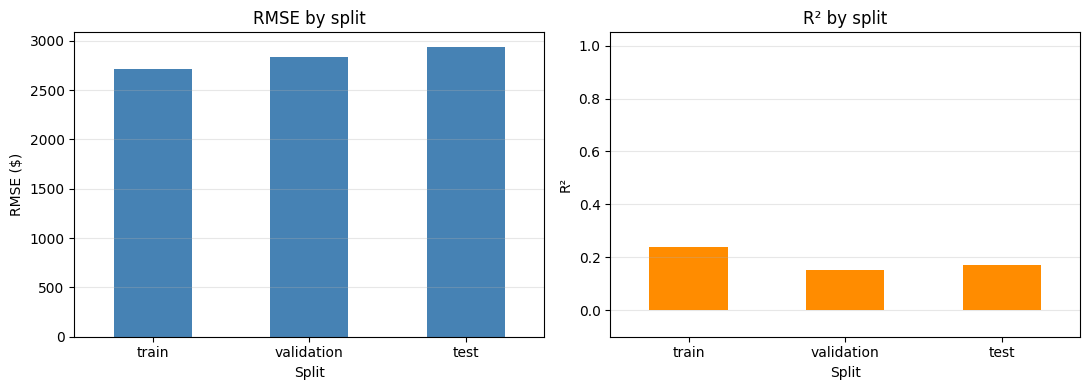

In [10]:
def eval_split(name, y_true, y_hat):
    mae = mean_absolute_error(y_true, y_hat)
    mse = mean_squared_error(y_true, y_hat)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_hat)
    return {"Split": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R²": r2}


y_pred_train = model.predict(X_train_proc)
y_pred_val = model.predict(X_val_proc)
y_pred_test = model.predict(X_test_proc)

metrics_rows = [
    eval_split("train", y_train, y_pred_train),
    eval_split("validation", y_val, y_pred_val),
    eval_split("test", y_test, y_pred_test),
]
metrics_df = pd.DataFrame(metrics_rows).set_index("Split")

train_val_gap = metrics_df.loc["train", "R²"] - metrics_df.loc["validation", "R²"]

print("All splits metrics (MAE and RMSE in dollars):")
metrics_print = metrics_df.copy()
metrics_print["MAE"] = metrics_print["MAE"].map(lambda x: f"${x:,.2f}")
metrics_print["RMSE"] = metrics_print["RMSE"].map(lambda x: f"${x:,.2f}")
for _col in ("MSE", "R²"):
    metrics_print[_col] = metrics_print[_col].map(lambda x: f"{x:,.4f}")
print(metrics_print.to_string())
print(f"\nTrain–Validation R² gap: {train_val_gap:.4f}")

if train_val_gap > 0.15:
    print("Interpretation: the model is still overfitting (train performance is much better than validation).")
elif metrics_df.loc["train", "R²"] < 0.20 and metrics_df.loc["validation", "R²"] < 0.20:
    print("Interpretation: the model is more likely underfitting (both train and validation scores are low).")
else:
    print("Interpretation: the train and validation scores are reasonably close, so the fit is more balanced.")

print("\nTest set metrics (requested):")
test_row = metrics_df.loc["test"]
print(f"MAE:  ${test_row['MAE']:,.2f}")
print(f"MSE:  {test_row['MSE']:,.4f}")
print(f"RMSE: ${test_row['RMSE']:,.2f}")
print(f"R²:   {test_row['R²']:,.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
metrics_df["RMSE"].plot(kind="bar", ax=axes[0], color="steelblue", rot=0)
axes[0].set_title("RMSE by split")
axes[0].set_ylabel("RMSE ($)")
axes[0].grid(axis="y", alpha=0.3)

metrics_df["R²"].plot(kind="bar", ax=axes[1], color="darkorange", rot=0)
axes[1].set_title("R² by split")
axes[1].set_ylabel("R²")
axes[1].set_ylim(min(-0.1, metrics_df["R²"].min() - 0.05), 1.05)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


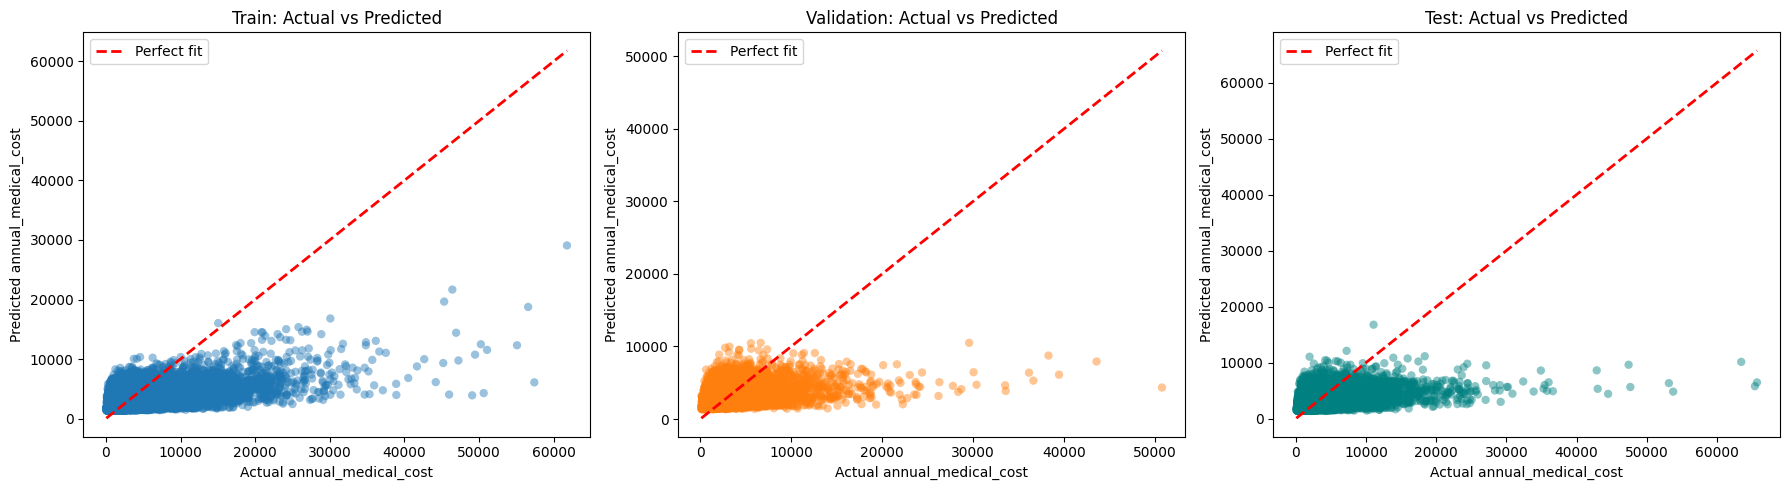

In [11]:
# Prediction vs Actual plots for all splits
split_data = [
    ("Train", y_train, y_pred_train, "tab:blue"),
    ("Validation", y_val, y_pred_val, "tab:orange"),
    ("Test", y_test, y_pred_test, "teal"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_true, y_hat, color) in zip(axes, split_data):
    ax.scatter(y_true, y_hat, alpha=0.45, edgecolors="none", color=color)
    lo = min(y_true.min(), y_hat.min())
    hi = max(y_true.max(), y_hat.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=2, label="Perfect fit")
    ax.set_title(f"{name}: Actual vs Predicted")
    ax.set_xlabel("Actual annual_medical_cost")
    ax.set_ylabel("Predicted annual_medical_cost")
    ax.legend()

plt.tight_layout()
plt.show()


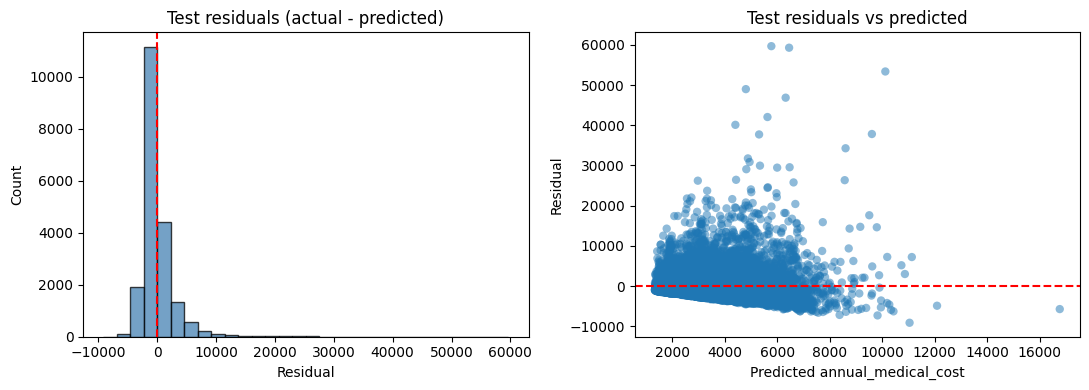

In [12]:
# Residuals on the test set: distribution and vs predicted value
residuals_test = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(residuals_test, bins=30, edgecolor="black", alpha=0.75, color="steelblue")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Test residuals (actual - predicted)")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Count")

axes[1].scatter(y_pred_test, residuals_test, alpha=0.5, edgecolors="none")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Test residuals vs predicted")
axes[1].set_xlabel("Predicted annual_medical_cost")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()


### Save the fitted pipeline (for reports or loading later)

The object **`evaluation_pipeline`** chains the **fitted preprocessor** + **fitted Random Forest** so you can call `predict` on **raw** `DataFrame` rows (same columns as `X`). Set `MODEL_SAVE_PATH` to your Drive folder in Colab, or a local path.

In [13]:
import joblib

evaluation_pipeline = Pipeline(
    [
        ("preprocess", preprocessor),
        ("regressor", model.named_steps["regressor"]),
    ]
)

# Example: Google Colab — change to your folder
MODEL_SAVE_PATH = "/content/drive/MyDrive/ML_Project/medical_insurance_rf_model.joblib"

try:
    joblib.dump(evaluation_pipeline, MODEL_SAVE_PATH)
    print("Saved:", MODEL_SAVE_PATH)
except Exception as e:
    print("Save skipped or failed (set a valid path):", e)


Saved: /content/drive/MyDrive/ML_Project/medical_insurance_rf_model.joblib


### Training objective ("cost function") and a quick diagnostic plot

In scikit-learn, `RandomForestRegressor` is trained so that each split **reduces impurity** measured with **mean squared error (MSE)** on the training sample in each node. Overall, that aligns with minimizing **prediction error** on the training data.

The plot below shows **per-example squared errors** on the **test** set — a histogram of \((y - \hat{y})^2\) — which relates directly to **MSE** (mean of those squared errors).

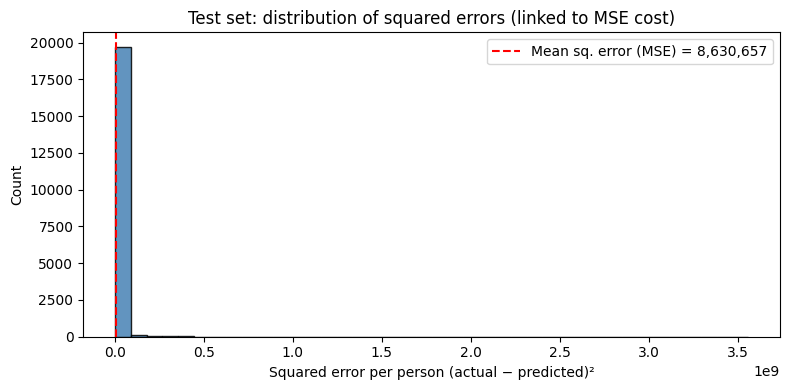

Test MSE: 8,630,656.76  |  RMSE: $2,937.80


In [14]:
# Uses test predictions from the Evaluation cell (`y_pred_test`)
sq_err = (y_test - y_pred_test) ** 2

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sq_err, bins=40, color="steelblue", edgecolor="black", alpha=0.85)
ax.axvline(np.mean(sq_err), color="red", linestyle="--", label=f"Mean sq. error (MSE) = {np.mean(sq_err):,.0f}")
ax.set_xlabel("Squared error per person (actual − predicted)²")
ax.set_ylabel("Count")
ax.set_title("Test set: distribution of squared errors (linked to MSE cost)")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"Test MSE: {np.mean(sq_err):,.2f}  |  RMSE: ${np.sqrt(np.mean(sq_err)):,.2f}"
)


## 7. Feature importance (after preprocessing)

Importances are taken from the fitted RandomForestRegressor (encoded feature names from **section 4.2**).

,feature,importance
15,num__chronic_count,0.215323
31,num__is_high_risk,0.163197
7,num__days_hospitalized_last_3yrs,0.137185
58,cat__smoker_Current,0.055814
6,num__hospitalizations_last_3yrs,0.052808
5,num__visits_last_year,0.040574
0,num__age,0.036632
4,num__bmi,0.028991
60,cat__smoker_Never,0.025533
1,num__income,0.025222


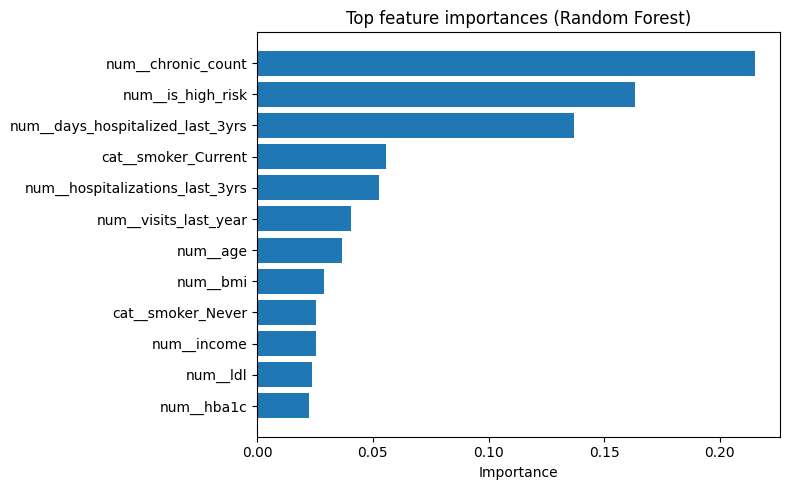

In [15]:
feature_names = feature_names_out
importances = model.named_steps["regressor"].feature_importances_

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False)
display(imp_df.head(15))

top = imp_df.head(12)
plt.figure(figsize=(8, 5))
plt.barh(top["feature"][::-1], top["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top feature importances (Random Forest)")
plt.tight_layout()
plt.show()


## 8. (Optional) Pure bagging baseline — BaggingRegressor

Random Forest is **bagging + random feature subsets**. For comparison, you can train **plain bagging** of decision trees (same bootstrap idea, all features at each split).

In [16]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor

base_tree = DecisionTreeRegressor(random_state=42)
bag = BaggingRegressor(
    estimator=base_tree,
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)

# Same preprocessed matrices as section 4a (no second fit of the encoder)
bag_pipeline = Pipeline([("regressor", bag)])
bag_pipeline.fit(X_train_proc, y_train)
y_bag_val = bag_pipeline.predict(X_val_proc)
y_bag_test = bag_pipeline.predict(X_test_proc)

print("BaggingRegressor (Decision Trees)")
print(
    f"Validation — RMSE: ${np.sqrt(mean_squared_error(y_val, y_bag_val)):,.2f}  "
    f"R²: {r2_score(y_val, y_bag_val):.4f}"
)
print(
    f"Test — RMSE: ${np.sqrt(mean_squared_error(y_test, y_bag_test)):,.2f}  "
    f"R²: {r2_score(y_test, y_bag_test):.4f}"
)


BaggingRegressor (Decision Trees)
Validation — RMSE: $2,919.29  R²: 0.1002
Test — RMSE: $3,005.40  R²: 0.1331
